# Introduction to Radar Reflectivity

## Learning Objectives
By the end of this tutorial, you will be able to:
1. Understand the concept of radar reflectivity
2. Load and visualize weather radar data
3. Apply the Marshall-Palmer Z-R relationship
4. Convert reflectivity to rainfall rate

---

## What is Reflectivity?

### The Physics Behind It

Weather radars work by:
1. **Transmitting** microwave energy
2. Some energy is **scattered** by precipitation particles
3. **Receiving** the backscattered signal

**Reflectivity** is the power of the returned signal, which tells us about the intensity of precipitation.

### Key Definitions

- **Reflectivity factor (Z)**: Measured in mm⁶·m⁻³
- **Reflectivity (Zₘ)**: Expressed in dBZ (decibels)
- **Conversion**: Zₘ (dBZ) = 10 × log₁₀(Z)

### What do the values mean?

| Reflectivity (dBZ) | Precipitation Type |
|--------------------|--------------------|
| < 20 | Light rain/drizzle |
| 20-40 | Moderate rain |
| 40-50 | Heavy rain |
| > 50 | Very heavy rain/hail |

---

## Setup: Import Required Libraries

In [ ]:
# Google colab only:
!pip install numpy pandas matplotlib cartopy xarray netCDF4 cmweather
# Restart the runtime after installing the packages

In [6]:
%matplotlib inline

import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
import cmweather.cm_colorblind as cmc

# Set better default plot style
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

print("Libraries imported successfully")

Libraries imported successfully


## Part 1: Loading and Exploring Radar Data

In [ ]:
# Load the radar data own python:
# dset = xr.open_dataset('data/502_20191123_210000_grid.nc')
# Load the radar data in Google Colab:
dset = xr.open_dataset('https://raw.githubusercontent.com/vlouf/monash-radar-workshop-2025/main/01-Introduction/data/502_20191123_210000_grid.nc')
refl = np.squeeze(dset.corrected_reflectivity.values)

# Let's explore the dataset structure
print("Dataset dimensions:")
print(dset.dims)
print("\nDataset coordinates:")
print(dset.coords)
print("\nReflectivity shape:", refl.shape)

Dataset dimensions:
FrozenMappingWarningOnValuesAccess({'time': 1, 'z': 41, 'y': 301, 'x': 301})

Dataset coordinates:
Coordinates:
  * time     (time) datetime64[ns] 8B 2019-11-23T21:00:48
  * z        (z) float64 328B 0.0 500.0 1e+03 1.5e+03 ... 1.9e+04 1.95e+04 2e+04
  * y        (y) float64 2kB -1.5e+05 -1.49e+05 -1.48e+05 ... 1.49e+05 1.5e+05
  * x        (x) float64 2kB -1.5e+05 -1.49e+05 -1.48e+05 ... 1.49e+05 1.5e+05

Reflectivity shape: (41, 301, 301)


### Understanding the Coordinate System

In [4]:
# Define coordinate system
x = np.linspace(-150e3, 150e3, 301)  # 300 km range in meters
y = np.linspace(-150e3, 150e3, 301)

# Set up the map projection (Azimuthal Equidistant)
projection = ccrs.AzimuthalEquidistant(
    central_longitude=dset.attrs['origin_longitude'],
    central_latitude=dset.attrs['origin_latitude']
)

print(f"Radar location: {dset.attrs['origin_latitude']:.2f}°N, {dset.attrs['origin_longitude']:.2f}°E")
print(f"Maximum range: {x.max()/1000:.0f} km")

Radar location: -12.31°N, 130.40°E
Maximum range: 150 km


## Part 2: Visualizing Reflectivity Data

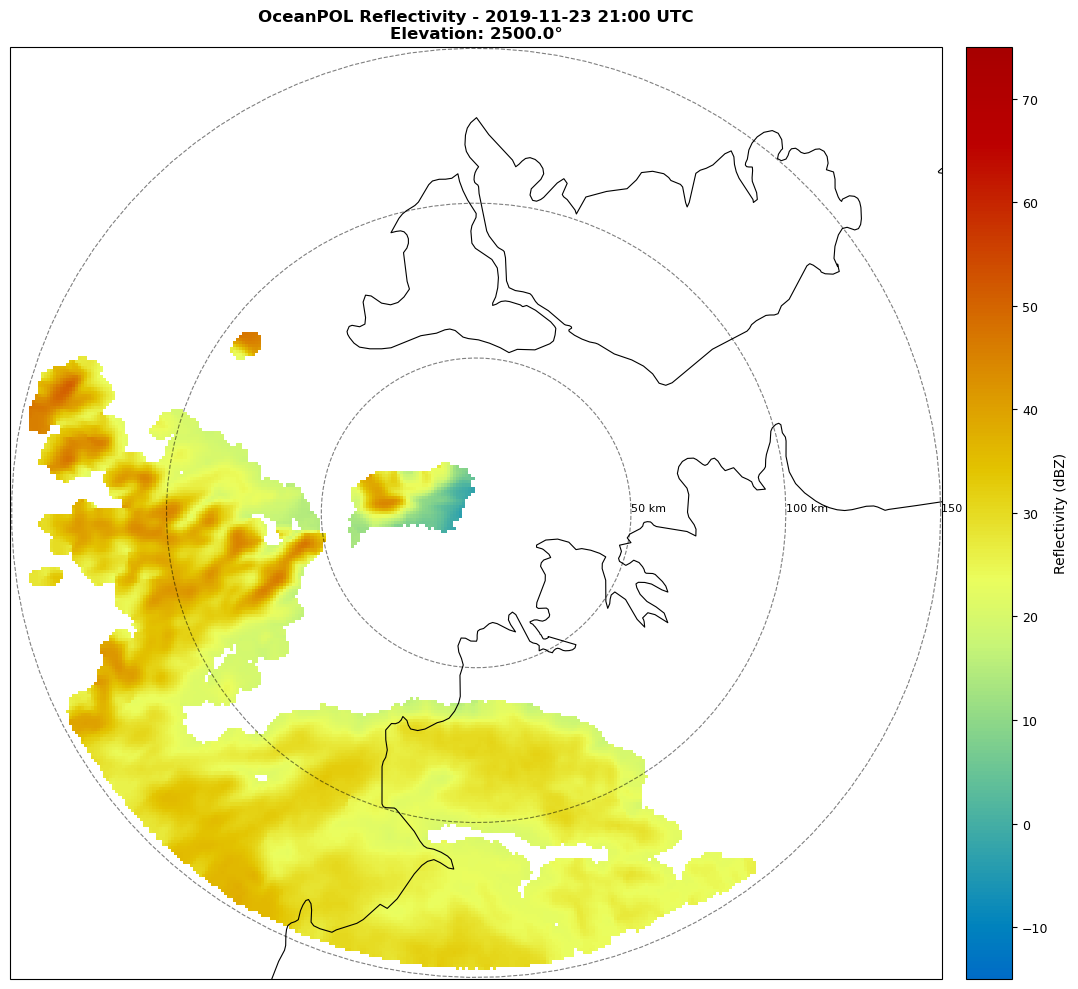

In [7]:
def plot_reflectivity(x, y, refl, projection, elevation_idx=5, **kwargs):
    """
    Plot radar reflectivity with coastlines and range rings.
    
    Parameters:
    -----------
    x, y : array-like
        Coordinate arrays
    refl : ndarray
        Reflectivity data (3D array)
    projection : cartopy projection
        Map projection
    elevation_idx : int
        Index of elevation angle to plot
    """
    datetime = pd.Timestamp(dset.time[0].to_pandas())
    
    fig = plt.figure(figsize=(12, 10))
    ax = plt.subplot(1, 1, 1, projection=projection)
    
    # Add coastlines
    ax.coastlines('10m', linewidth=0.8)
    
    # Plot reflectivity
    im = ax.pcolormesh(x, y, refl[elevation_idx, :, :], 
                       vmin=-15, vmax=75, 
                       cmap=cmc.HomeyerRainbow,
                       shading='auto')
    
    # Add range rings
    theta = np.linspace(0, 2 * np.pi, 100)
    for r, label in zip([50e3, 100e3, 150e3], ['50 km', '100 km', '150 km']):
        ax.plot(r * np.cos(theta), r * np.sin(theta), 
                'k--', linewidth=0.8, alpha=0.5)
        # Add range labels
        ax.text(r, 0, label, ha='left', va='bottom', fontsize=8)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, label='Reflectivity (dBZ)', pad=0.02)
    cbar.ax.tick_params(labelsize=9)
    
    # Title
    plt.title(f'OceanPOL Reflectivity - {datetime.strftime("%Y-%m-%d %H:%M UTC")}\n'
              f'Elevation: {dset.z[elevation_idx].values:.1f}°', 
              fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    return fig, ax

# Create the plot
fig, ax = plot_reflectivity(x, y, refl, projection)
plt.show()

### 🔍 Interpretation Questions

Look at the plot above and consider:
1. Where is the most intense precipitation?
2. What is the approximate maximum reflectivity value?
3. Can you identify different precipitation structures (e.g., convective cells, stratiform rain)?

---

## Part 3: The Marshall-Palmer Relationship

### Theory

The Marshall-Palmer relationship (1948) is an empirical formula that relates radar reflectivity to rainfall rate:

$$Z = 200R^{1.6}$$

Where:
- **Z** = reflectivity factor (mm⁶·m⁻³)
- **R** = rainfall rate (mm·h⁻¹)

To convert reflectivity in dBZ to rainfall rate:

$$R = \left(\frac{10^{Z_m/10}}{200}\right)^{1/1.6}$$

### Why is this important?

- Radars measure reflectivity, but we want to know rainfall rates
- This relationship allows operational rainfall estimation
- Different relationships exist for different precipitation types

### Visualizing the Relationship

In [8]:
# Define the Marshall-Palmer relationship
def z_from_r(r):
    """Calculate Z from rainfall rate R"""
    return 200 * r ** 1.6

def r_from_z(z):
    """Calculate rainfall rate R from reflectivity factor Z"""
    return (z / 200) ** (1/1.6)

def r_from_dbz(dbz):
    """Calculate rainfall rate R from reflectivity in dBZ"""
    z = 10 ** (dbz / 10)
    return r_from_z(z)

# Create sample data
rainrate = np.logspace(-1, 3, 100)  # 0.1 to 1000 mm/h
reflectivity = z_from_r(rainrate)
reflectivity_dbz = 10 * np.log10(reflectivity)

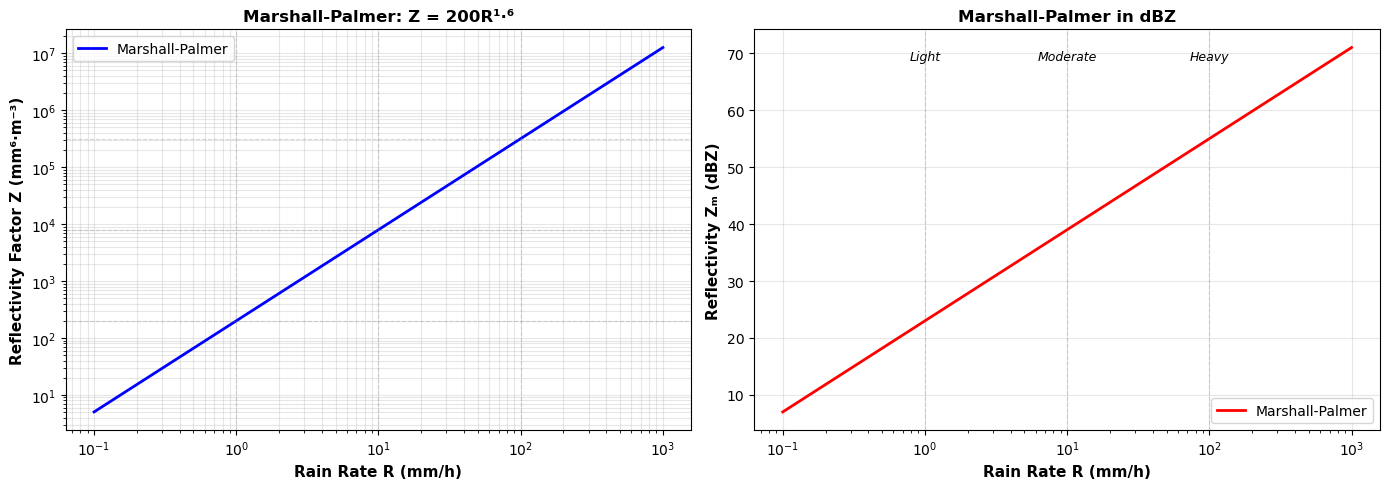


Reference values:
Rain Rate | Reflectivity
----------|-------------
  1 mm/h  |  23.0 dBZ
  5 mm/h  |  34.2 dBZ
 10 mm/h  |  39.0 dBZ
 25 mm/h  |  45.4 dBZ
 50 mm/h  |  50.2 dBZ
100 mm/h  |  55.0 dBZ


In [10]:
# Create a comprehensive visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Z vs R (log-log)
ax1.plot(rainrate, reflectivity, 'b-', linewidth=2, label='Marshall-Palmer')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Rain Rate R (mm/h)', fontsize=11, fontweight='bold')
ax1.set_ylabel(r'Reflectivity Factor Z (mm⁶·m⁻³)', fontsize=11, fontweight='bold')
ax1.set_title('Marshall-Palmer: Z = 200R¹·⁶', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, which='both')
ax1.legend(fontsize=10)

# Add reference lines
for r_val, label in [(1, '1 mm/h'), (10, '10 mm/h'), (100, '100 mm/h')]:
    z_val = z_from_r(r_val)
    ax1.axvline(r_val, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
    ax1.axhline(z_val, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)

# Right plot: dBZ vs R (semi-log)
ax2.plot(rainrate, reflectivity_dbz, 'r-', linewidth=2, label='Marshall-Palmer')
ax2.set_xscale('log')
ax2.set_xlabel('Rain Rate R (mm/h)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Reflectivity Zₘ (dBZ)', fontsize=11, fontweight='bold')
ax2.set_title('Marshall-Palmer in dBZ', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

# Add reference lines
for r_val, dbz_val, label in [(1, 23, 'Light'), (10, 41, 'Moderate'), (100, 59, 'Heavy')]:
    ax2.axvline(r_val, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
    ax2.text(r_val, ax2.get_ylim()[1]*0.95, label, 
             ha='center', va='top', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

print("\nReference values:")
print("Rain Rate | Reflectivity")
print("----------|-------------")
for r in [1, 5, 10, 25, 50, 100]:
    dbz = 10 * np.log10(z_from_r(r))
    print(f"{r:3.0f} mm/h  | {dbz:5.1f} dBZ")

---

## 📝 Exercise 1: Calculate Rainfall Rate from Reflectivity

**Task**: Using the Marshall-Palmer relationship, convert the reflectivity data to rainfall rate and create a visualization.

**Steps**:
1. Convert reflectivity from dBZ to Z (mm⁶·m⁻³)
2. Apply the inverse Marshall-Palmer equation to get rainfall rate
3. Create a plot similar to the reflectivity plot, but showing rainfall rate
4. Use an appropriate colormap and scale

**Hints**:
- Remember: Z = 10^(Zₘ/10)
- R = (Z/200)^(1/1.6)
- Consider using a logarithmic color scale for better visualization
- Typical rainfall rates range from 0.1 to 100+ mm/h

In [ ]:
# Your solution here
# Step 1: Convert dBZ to Z
z_linear = # YOUR CODE

# Step 2: Calculate rainfall rate
rainfall_rate = # YOUR CODE

# Step 3: Create the plot
# YOUR CODE

### Solution (Run this cell after attempting the exercise)


Rainfall Statistics:
  Maximum rainfall rate: 55.7 mm/h
  Mean rainfall rate: 3.2 mm/h
  Area with rain > 1 mm/h: 61004 km²


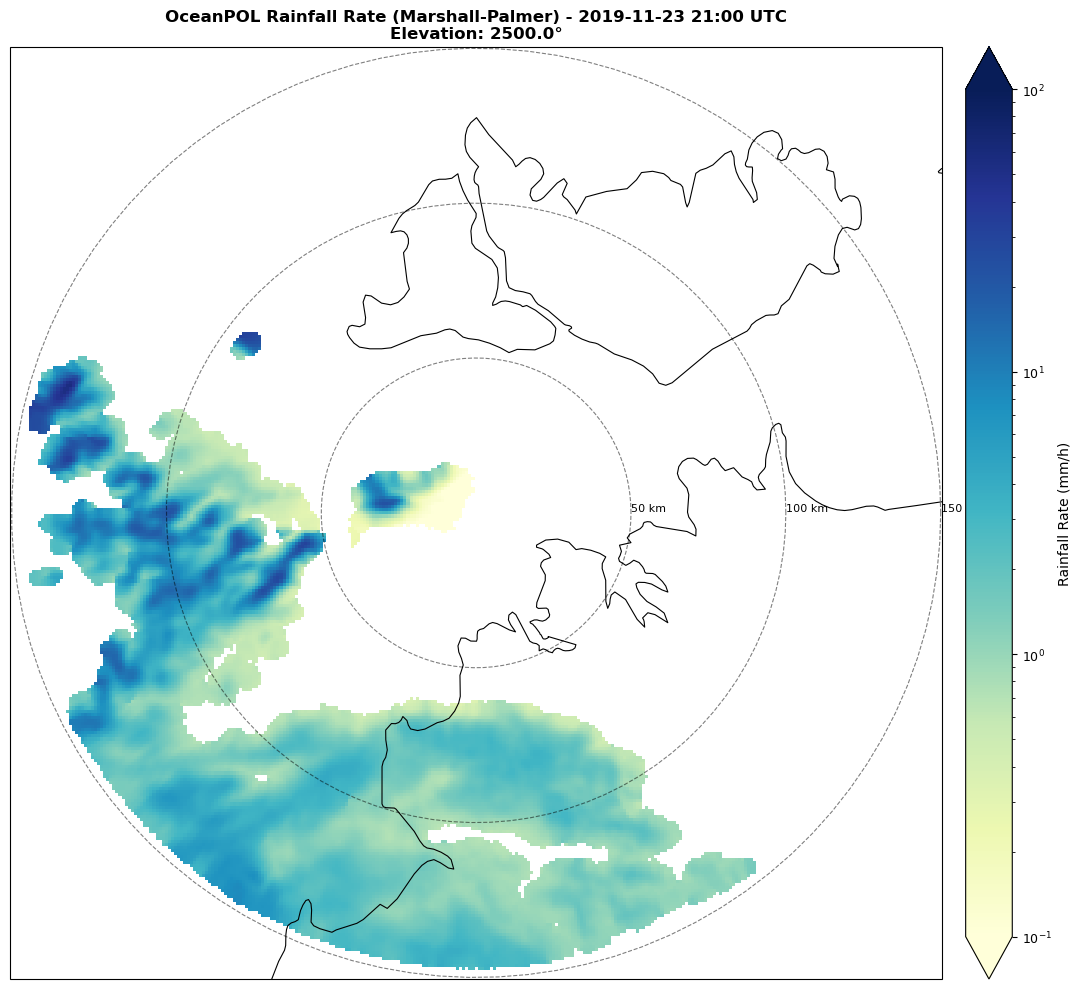

In [12]:
# Solution
def plot_rainfall_rate(x, y, refl_dbz, projection, elevation_idx=5):
    """
    Convert reflectivity to rainfall rate and plot.
    """
    # Convert dBZ to Z (linear scale)
    z_linear = 10 ** (refl_dbz / 10)
    
    # Calculate rainfall rate using Marshall-Palmer
    rainfall_rate = (z_linear / 200) ** (1/1.6)
    
    # Handle invalid values (negative reflectivity gives NaN)
    rainfall_rate = np.where(np.isfinite(rainfall_rate), rainfall_rate, 0)
    
    datetime = pd.Timestamp(dset.time[0].to_pandas())
    
    fig = plt.figure(figsize=(12, 10))
    ax = plt.subplot(1, 1, 1, projection=projection)
    
    ax.coastlines('10m', linewidth=0.8)
    
    # Use logarithmic normalization for better visualization
    from matplotlib.colors import LogNorm
    
    im = ax.pcolormesh(x, y, rainfall_rate[elevation_idx, :, :],
                       norm=LogNorm(vmin=0.1, vmax=100),
                       cmap='YlGnBu',
                       shading='auto')
    
    # Add range rings
    theta = np.linspace(0, 2 * np.pi, 100)
    for r, label in zip([50e3, 100e3, 150e3], ['50 km', '100 km', '150 km']):
        ax.plot(r * np.cos(theta), r * np.sin(theta), 
                'k--', linewidth=0.8, alpha=0.5)
        ax.text(r, 0, label, ha='left', va='bottom', fontsize=8)
    
    cbar = plt.colorbar(im, ax=ax, label='Rainfall Rate (mm/h)', pad=0.02, extend='both')
    cbar.ax.tick_params(labelsize=9)
    
    plt.title(f'OceanPOL Rainfall Rate (Marshall-Palmer) - {datetime.strftime("%Y-%m-%d %H:%M UTC")}\n'
              f'Elevation: {dset.z[elevation_idx].values:.1f}°',
              fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    
    # Print statistics
    valid_rainfall = rainfall_rate[elevation_idx][rainfall_rate[elevation_idx] > 0.1]
    print(f"\nRainfall Statistics:")
    print(f"  Maximum rainfall rate: {np.nanmax(valid_rainfall):.1f} mm/h")
    print(f"  Mean rainfall rate: {np.nanmean(valid_rainfall):.1f} mm/h")
    print(f"  Area with rain > 1 mm/h: {np.sum(valid_rainfall > 1) * 4:.0f} km²")  # Assuming 2km resolution
    
    return fig, ax, rainfall_rate

# Create the plot
fig, ax, rainfall = plot_rainfall_rate(x, y, refl, projection)
plt.show()

---

## 🧪 Extension Activity: Comparing Different Z-R Relationships

The Marshall-Palmer relationship is not universal. Different types of precipitation have different drop size distributions, leading to different Z-R relationships:

| Precipitation Type | Z-R Relationship | Application |
|--------------------|------------------|-------------|
| Convective rain | Z = 300R¹·⁴ | Thunderstorms |
| Stratiform rain | Z = 200R¹·⁶ | Widespread rain (Marshall-Palmer) |
| Tropical rain | Z = 250R¹·² | Tropical systems |
| Snow | Z = 2000R² | Snowfall |

### Challenge

Create a comparison plot showing how different Z-R relationships estimate rainfall rate for the same reflectivity values.

In [ ]:
# Extension: Compare different Z-R relationships
def compare_zr_relationships():
    dbz_range = np.linspace(10, 60, 100)
    z = 10 ** (dbz_range / 10)
    
    # Different relationships
    r_marshall_palmer = (z / 200) ** (1/1.6)
    r_convective = (z / 300) ** (1/1.4)
    r_tropical = (z / 250) ** (1/1.2)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(dbz_range, r_marshall_palmer, 'b-', linewidth=2, label='Stratiform (Z=200R¹·⁶)')
    ax.plot(dbz_range, r_convective, 'r-', linewidth=2, label='Convective (Z=300R¹·⁴)')
    ax.plot(dbz_range, r_tropical, 'g-', linewidth=2, label='Tropical (Z=250R¹·²)')
    
    ax.set_xlabel('Reflectivity (dBZ)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Rainfall Rate (mm/h)', fontsize=11, fontweight='bold')
    ax.set_title('Comparison of Z-R Relationships', fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Key Insight:")
    print("Different precipitation types require different Z-R relationships!")
    print("Using the wrong relationship can lead to significant errors in rainfall estimation.")

compare_zr_relationships()

---

## 📚 Summary

In this tutorial, you learned:

1. ✅ **Radar reflectivity** represents the power of the returned signal from precipitation
2. ✅ **dBZ** is the logarithmic representation of reflectivity (Zₘ = 10 log₁₀ Z)
3. ✅ The **Marshall-Palmer relationship** (Z = 200R¹·⁶) converts reflectivity to rainfall rate
4. ✅ How to **visualize radar data** with proper map projections
5. ✅ Different precipitation types require **different Z-R relationships**

### Further Reading

- Marshall, J. S., & Palmer, W. M. (1948). The distribution of raindrops with size. *Journal of Meteorology*, 5(4), 165-166.
- Battan, L. J. (1973). *Radar observation of the atmosphere*. University of Chicago Press.
- Doviak, R. J., & Zrnić, D. S. (1993). *Doppler radar and weather observations*. Academic press.

### Next Steps

- Explore dual-polarization radar variables
- Learn about QPE (Quantitative Precipitation Estimation) algorithms
- Study attenuation correction techniques
- Investigate machine learning approaches for precipitation classification